# 02 — Delivery reliability & customer satisfaction
### Olist Brazilian E-Commerce · `retail-platform-analytics`

The exploratory analysis (`01`) found the single strongest signal in the data: **late delivery
craters review scores** (on-time orders average 4.30★ vs 2.57★ for late). This notebook turns that
headline into a **defensible, controlled finding**, tests what *else* matters, and maps its geography.
It covers three questions from the EDA backlog:

- **A — What actually drives dissatisfaction?** Lateness, or confounders like distance, weight, category?
- **B — How accurate are the delivery estimates**, and why do some regions get tight ones?
- **D — Is delivery *equitable* across Brazil**, and where is it a *logistics* problem vs a *distance* one?

**Method:** descriptive analysis + controlled cuts (grouped breakdowns and correlations in SQL +
pandas). No predictive model — the goal is to *explain* the pattern transparently.

## Data caveats & conventions

- **Delivered orders only** (`status = 'delivered'`, ~97% of orders) — delivery time, on-time status and
  the estimate buffer only exist once an order reaches the customer.
- **Distance is computed, not given.** The marts dropped lat/long, so we rebuild a zip→coordinate lookup
  from `stg_geolocation` and compute the **great-circle (haversine) km** between seller and customer;
  averaged over sellers for multi-seller orders. Coverage ~99%.
- **Order-level vs exact.** The main dataframe carries an *order average* weight and a single
  representative category — fine for the order-grain delivery analysis and the correlation overview. For
  the weight/category cuts (§5) we switch to **single-item orders (~88%)**, where both are *exact*.
- **On-time** = delivered on/before `estimated_delivery_date`. **days_early / buffer** =
  `estimated_delivery_date − actual delivery date` (days; **+ = early, − = late**).
- **⚠️ Correlation, not a controlled experiment.** The controlled cuts hold one confounder constant at a
  time; they strongly suggest causation but don't prove it (see §8).

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    df = db.query(sql)
    df.columns = df.columns.str.lower()   # Snowflake returns UPPERCASE column names
    return df

def gap_table(frame, by):
    """Within each level of `by`, mean review score for on-time vs late orders, plus the gap between
    them (= how much lateness costs within that band)."""
    f = frame.dropna(subset=["review_score", "on_time"]).copy()
    f["on_time"] = f["on_time"].astype(bool)
    g = f.groupby([by, "on_time"], observed=True)["review_score"].mean().unstack()   # rows=`by`, cols=on_time
    g = g.rename(columns={True: "ontime_score", False: "late_score"})
    g["lateness_penalty"] = g["ontime_score"] - g["late_score"]
    return g.reset_index()

print("Connected:", q("select current_schema() as s").iloc[0, 0])

Connected: DEV_MARTS


## 1. The signal we are chasing

Reproduce `01`'s headline at the order level — average review score for on-time vs late deliveries.

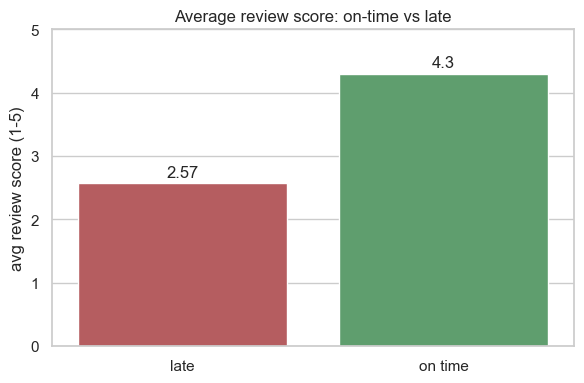

,label,orders,avg_score
0,late,7566,2.57
1,on time,87146,4.30


In [2]:
# Average review score split by whether the order beat its estimated delivery date.
headline = q('''
    select is_delivered_on_time, count(*) as orders, round(avg(review_score), 2) as avg_score
    from dev_marts.fct_orders
    where status = 'delivered' and review_score is not null and is_delivered_on_time is not null
    group by 1 order by 1
''')
headline["label"] = headline["is_delivered_on_time"].map({True: "on time", False: "late"})

fig, ax = plt.subplots(figsize=(6, 4))
# hue=x + legend=False colours the two bars (red=late, green=on time); seaborn->=0.14 safe.
sns.barplot(data=headline, x="label", y="avg_score", ax=ax, hue="label",
            palette=["#C44E52", "#55A868"], legend=False, dodge=False)
ax.set_title("Average review score: on-time vs late"); ax.set_xlabel(""); ax.set_ylabel("avg review score (1-5)")
ax.set_ylim(0, 5)
for i, r in headline.iterrows():
    ax.text(i, r["avg_score"] + 0.1, f"{r['avg_score']}", ha="center")
plt.tight_layout(); plt.show()
headline[["label", "orders", "avg_score"]]

**A ~1.7-point gap** on a 5-point scale — enormous. But late orders might just be the *hard* ones
(far, heavy, certain categories). The rest of the notebook asks whether the gap survives once we control
for those confounders, and what *else* moves the score.

## 2. Building seller → customer distance

The marts don't carry coordinates, so we reconstruct them from `stg_geolocation` and compute the
great-circle distance per order. **One heavy query** builds an order-level dataframe with everything the
notebook needs; we slice it in pandas from there.

In [3]:
# One order per row: delivery facts + computed seller->customer distance. NOTE weight_g and
# category_name here are ORDER-LEVEL aggregates (avg / representative) — fine for the order-grain
# delivery analysis and the §8 correlation overview; §5 uses exact single-item orders instead.
orders = q('''
    with zip as (  -- average lat/long per zip prefix (stg_geolocation has many points per zip)
        select zip_code_prefix, avg(latitude) as lat, avg(longitude) as lng
        from dev_staging.stg_geolocation group by 1
    ),
    order_seller as (select distinct order_id, seller_id from dev_marts.fct_order_items),
    seller_pt as (  -- each order's seller location(s)
        select os.order_id, z.lat as slat, z.lng as slng
        from order_seller os
        join dev_marts.dim_sellers s on os.seller_id = s.seller_id
        join zip z on s.zip_code_prefix = z.zip_code_prefix
    ),
    order_weight as (  -- avg item weight + a representative category per order
        select oi.order_id, avg(p.weight_g) as weight_g, max(oi.category_name) as category_name
        from dev_marts.fct_order_items oi
        join dev_marts.dim_products p on oi.product_id = p.product_id
        group by 1
    ),
    base as (  -- order facts + the customer (delivery) location; est_buffer_days = days early vs estimate
        select o.order_id, o.delivery_state, o.status, o.delivery_time_days,
               o.is_delivered_on_time, o.review_score,
               datediff('day', o.delivered_to_customer_at, o.estimated_delivery_date) as est_buffer_days,
               zc.lat as clat, zc.lng as clng
        from dev_marts.fct_orders o
        join zip zc on o.delivery_zip_code_prefix = zc.zip_code_prefix
    )
    -- haversine km between seller and customer; averaged over sellers for multi-seller orders
    select b.order_id, b.delivery_state, b.status, b.delivery_time_days,
           b.is_delivered_on_time, b.review_score, b.est_buffer_days,
           w.weight_g, w.category_name,
           avg(2 * 6371 * asin(sqrt(
               pow(sin(radians(b.clat - sp.slat) / 2), 2)
               + cos(radians(sp.slat)) * cos(radians(b.clat))
               * pow(sin(radians(b.clng - sp.slng) / 2), 2)))) as dist_km
    from base b
    left join seller_pt sp on b.order_id = sp.order_id
    left join order_weight w on b.order_id = w.order_id
    group by 1, 2, 3, 4, 5, 6, 7, 8, 9
''')

for c in ["delivery_time_days", "review_score", "est_buffer_days", "weight_g", "dist_km"]:
    orders[c] = pd.to_numeric(orders[c], errors="coerce")
orders["on_time"] = orders["is_delivered_on_time"].astype("boolean")   # nullable boolean

# Keep delivered orders that have a computable distance; this `d` powers most sections below.
d = orders[(orders["status"] == "delivered") & orders["dist_km"].notna()].copy()
# The promised window (days from purchase to the estimate) = how early we arrived + how long it took.
d["est_window"] = d["est_buffer_days"] + d["delivery_time_days"]
print(f"{len(orders):,} orders pulled | {len(d):,} delivered with distance "
      f"({100*len(d)/len(orders):.1f}% coverage)")
print(f"median distance {d['dist_km'].median():.0f} km | mean {d['dist_km'].mean():.0f} km")

99,163 orders pulled | 96,002 delivered with distance (96.8% coverage)
median distance 434 km | mean 601 km


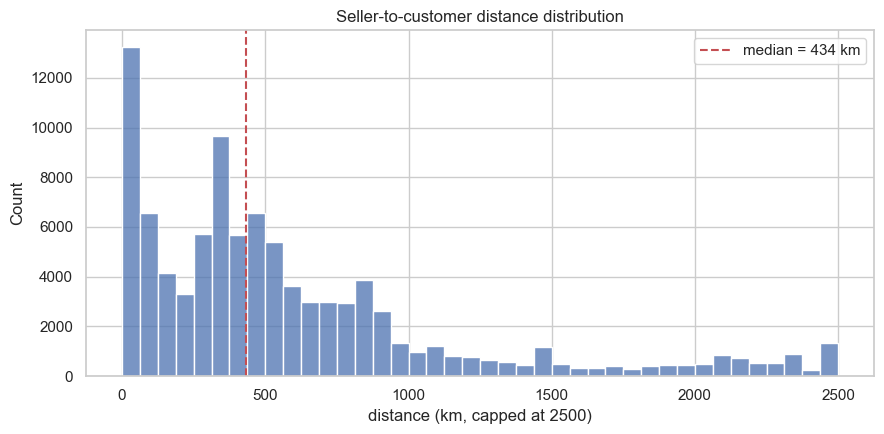

In [4]:
# Distance distribution (clipped at 2500km so the long tail doesn't squash the bulk of the mass).
fig, ax = plt.subplots()
sns.histplot(d["dist_km"].clip(upper=2500), bins=40, color="#4C72B0", ax=ax)
ax.axvline(d["dist_km"].median(), color="#C44E52", ls="--", label=f"median = {d['dist_km'].median():.0f} km")
ax.set_title("Seller-to-customer distance distribution")
ax.set_xlabel("distance (km, capped at 2500)"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Delivery performance by distance

Bucket orders by distance and look at delivery time, on-time rate and review score together.

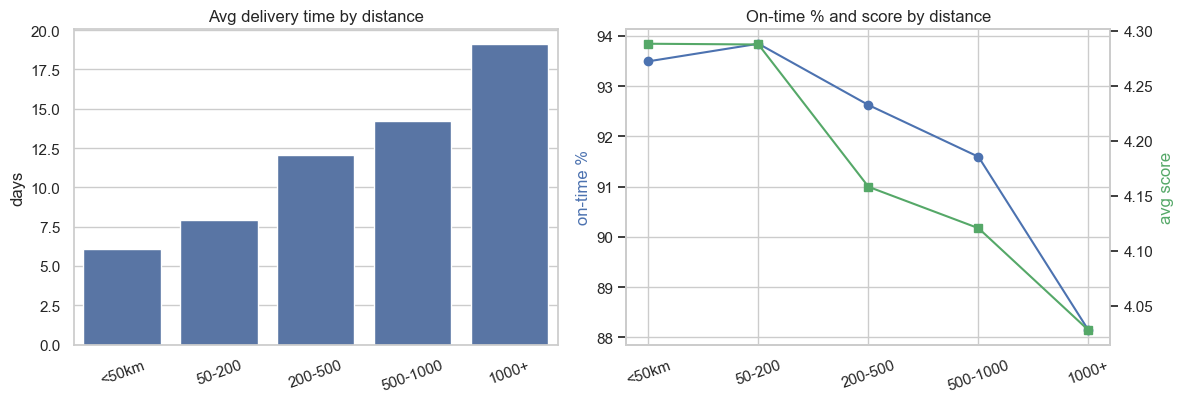

,dist_bucket,orders,avg_days,on_time_pct,avg_score
0,<50km,11665,6.10,93.49,4.29
1,50-200,12898,7.94,93.84,4.29
2,200-500,30314,12.05,92.62,4.16
3,500-1000,25753,14.25,91.59,4.12
4,1000+,15349,19.09,88.14,4.03


In [5]:
# Bucket by distance, then average delivery time / on-time rate / score within each band.
d["dist_bucket"] = pd.cut(d["dist_km"], [0, 50, 200, 500, 1000, np.inf],
                           labels=["<50km", "50-200", "200-500", "500-1000", "1000+"])
by_dist = d.groupby("dist_bucket", observed=True).agg(
    orders=("order_id", "size"),
    avg_days=("delivery_time_days", "mean"),
    on_time_pct=("on_time", "mean"),
    avg_score=("review_score", "mean")).reset_index()
by_dist["on_time_pct"] *= 100    # mean of a 0/1 flag → percentage

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(data=by_dist, x="dist_bucket", y="avg_days", ax=ax1, color="#4C72B0")
ax1.set_title("Avg delivery time by distance"); ax1.set_xlabel(""); ax1.set_ylabel("days")
ax1.tick_params(axis="x", rotation=20)
# Twin axes: on-time % (blue) and avg review score (green). Blue avoids implying "on-time" is bad.
ax2.plot(by_dist["dist_bucket"], by_dist["on_time_pct"], marker="o", color="#4C72B0", label="on-time %")
ax2b = ax2.twinx()
ax2b.plot(by_dist["dist_bucket"], by_dist["avg_score"], marker="s", color="#55A868", label="avg score")
ax2.set_ylabel("on-time %", color="#4C72B0"); ax2b.set_ylabel("avg score", color="#55A868")
ax2.set_title("On-time % and score by distance"); ax2.tick_params(axis="x", rotation=20); ax2b.grid(False)
plt.tight_layout(); plt.show()
by_dist.round(2)

**Interpretation.** A clean monotonic gradient: distance roughly **triples delivery time** (~6 days
under 50km → ~19 days beyond 1000km), drops on-time rate (~94% → ~88%), and pulls review scores down
(~4.29 → ~4.03). Distance clearly tracks a worse experience — but *through what mechanism*? The next
sections isolate it.

## 4. Is it distance, or is it lateness? (controlled cut #1)

If distance hurt scores *directly*, even **on-time** far-away orders would score poorly. If distance
hurts only *by causing lateness*, then within each distance band the on-time score should stay high. Test
it by splitting each distance band into on-time vs late.

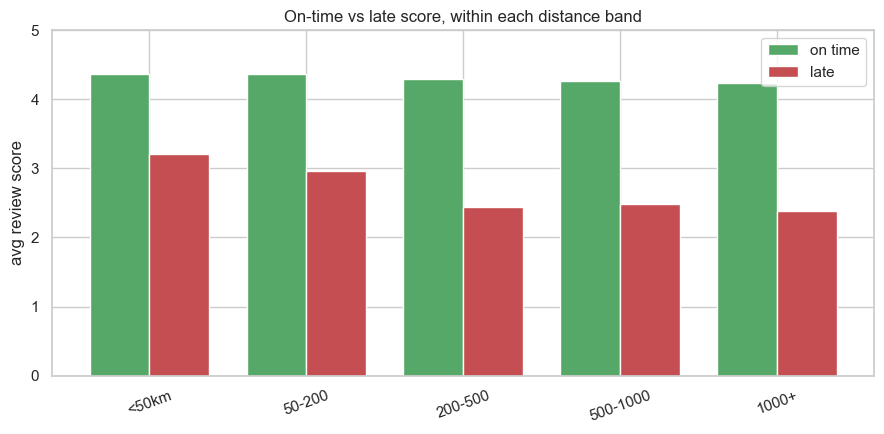

on_time,dist_bucket,late_score,ontime_score,lateness_penalty
0,<50km,3.20,4.36,1.16
1,50-200,2.96,4.37,1.41
2,200-500,2.45,4.29,1.85
3,500-1000,2.48,4.27,1.79
4,1000+,2.38,4.24,1.86


In [6]:
dist_gap = gap_table(d, "dist_bucket")

fig, ax = plt.subplots()
x = np.arange(len(dist_gap)); w = 0.38          # place the two bars side by side around each x tick:
ax.bar(x - w/2, dist_gap["ontime_score"], w, label="on time", color="#55A868")   # on-time: half a width left
ax.bar(x + w/2, dist_gap["late_score"], w, label="late", color="#C44E52")        # late: half a width right
ax.set_xticks(x); ax.set_xticklabels(dist_gap["dist_bucket"], rotation=20)
ax.set_ylim(0, 5); ax.set_ylabel("avg review score"); ax.set_title("On-time vs late score, within each distance band")
ax.legend()
plt.tight_layout(); plt.show()
dist_gap.round(2)

**Interpretation — the key finding.** Hold distance constant and the story is unmistakable:
**on-time orders score ~4.2–4.4 in every distance band**, while **late orders score ~2.4–3.1**
everywhere. The ~1.7-point penalty is *not* explained by distance — a far order that still arrives on time
is rated almost as highly as a local one. **Distance matters only because it makes orders late.**

### 4b. Satisfaction is a gradient around the deadline

The on-time/late split is really a **cliff on a continuous curve**. Score orders by how many days they
beat or missed the promised date: a small miss already hurts, a big miss is catastrophic, and extra
earliness helps only up to a point.

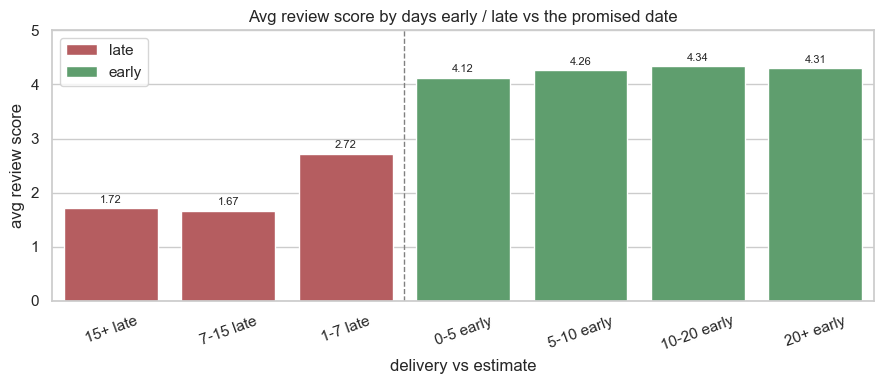

,vs_estimate,review_score,side
0,15+ late,1.72,late
1,7-15 late,1.67,late
2,1-7 late,2.72,late
3,0-5 early,4.12,early
4,5-10 early,4.26,early
5,10-20 early,4.34,early
6,20+ early,4.31,early


In [7]:
# Score across the full spectrum of days early/late vs the estimate (est_buffer_days: + = early).
grad = d.dropna(subset=["review_score", "est_buffer_days"]).copy()
# right=False → intervals are [a, b), which cleanly separates late (<0) from early (>=0) at the 0 boundary.
grad["vs_estimate"] = pd.cut(grad["est_buffer_days"], [-np.inf, -15, -7, 0, 5, 10, 20, np.inf], right=False,
                             labels=["15+ late", "7-15 late", "1-7 late", "0-5 early",
                                     "5-10 early", "10-20 early", "20+ early"])
gsum = grad.groupby("vs_estimate", observed=True)["review_score"].mean().reset_index()
gsum["side"] = np.where(gsum["vs_estimate"].astype(str).str.contains("late"), "late", "early")

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=gsum, x="vs_estimate", y="review_score", ax=ax, hue="side",
            palette={"late": "#C44E52", "early": "#55A868"}, dodge=False)
ax.axvline(2.5, color="grey", ls="--", lw=1)     # boundary between the last-late and first-early bucket
ax.set_ylim(0, 5); ax.set_title("Avg review score by days early / late vs the promised date")
ax.set_xlabel("delivery vs estimate"); ax.set_ylabel("avg review score"); ax.tick_params(axis="x", rotation=20)
ax.legend(title="")
for i, r in gsum.iterrows():
    ax.text(i, r["review_score"] + 0.1, f"{r['review_score']:.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
gsum.round(2)

**Interpretation.** It's a **cliff, not a step.** Among *late* orders the damage scales with the
miss — **1–7 days late already drops to ~2.8★, and 7+ days late craters to ~1.7★**. Cross to the early
side and scores jump to **4.1–4.3★**, peaking around 10–20 days early (extra cushion beyond that adds
nothing). The estimate date is a **hard threshold**, and *degree* of lateness matters: a near-miss is far
less damaging than a big one.

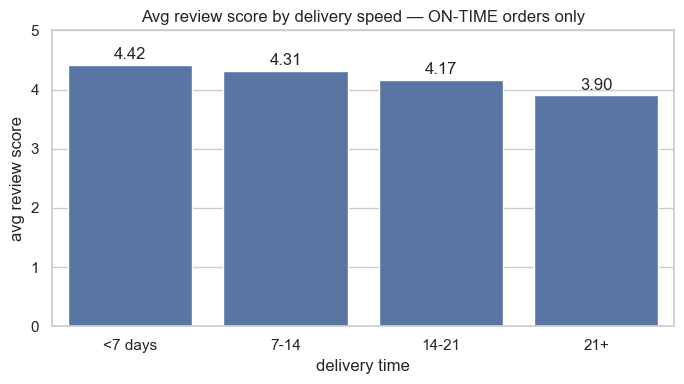

on-time only — corr(delivery days, score): -0.123 | corr(days early, score): 0.024


In [8]:
# A second, independent axis: among ON-TIME orders, does raw delivery SPEED still matter?
ot = d.dropna(subset=["on_time", "review_score"]).copy()
ot = ot[ot["on_time"].astype(bool)]          # on-time orders only
ot["speed_bucket"] = pd.cut(ot["delivery_time_days"], [0, 7, 14, 21, np.inf],
                            labels=["<7 days", "7-14", "14-21", "21+"])
by_speed = ot.groupby("speed_bucket", observed=True)["review_score"].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=by_speed, x="speed_bucket", y="review_score", ax=ax, color="#4C72B0")
ax.set_ylim(0, 5); ax.set_title("Avg review score by delivery speed — ON-TIME orders only")
ax.set_xlabel("delivery time"); ax.set_ylabel("avg review score")
for i, r in by_speed.iterrows():
    ax.text(i, r["review_score"] + 0.1, f"{r['review_score']:.2f}", ha="center")
plt.tight_layout(); plt.show()
# Is it raw speed, or the size of the early cushion? Compare the two correlations (on-time only).
print("on-time only — corr(delivery days, score):",
      round(ot["delivery_time_days"].corr(ot["review_score"]), 3),
      "| corr(days early, score):", round(ot["est_buffer_days"].corr(ot["review_score"]), 3))

**Interpretation.** Even among on-time orders, **faster is better**: score slides from **~4.43**
(under a week) to **~3.94** (21+ days) — and it's *speed*, not the cushion (score↔delivery-days ≈ −0.12,
but ↔size-of-buffer ≈ 0.02). This is why the far, on-time orders in §3 dipped slightly: they simply took
longer. **Lateness is the primary lever; absolute delivery speed is a secondary one.**

## 5. Robustness: weight & category (exact, single-item orders)

Does the lateness effect hold within item **weight** bands and top **categories** — or is weight itself a
driver? Here we use **single-item orders only (~88% of all orders)**, so each order's weight and category
are *exact* (no order-level averaging).

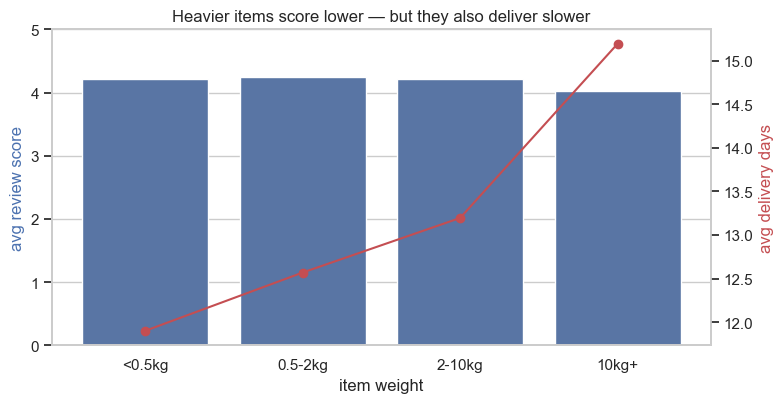

,weight_bucket,orders,avg_score,avg_delivery_days,ontime_score,late_score,lateness_penalty
0,<0.5kg,36375,4.22,11.90,4.36,2.59,1.77
1,0.5-2kg,29337,4.24,12.57,4.39,2.60,1.78
2,2-10kg,15661,4.21,13.19,4.37,2.54,1.83
3,10kg+,3932,4.03,15.19,4.22,2.47,1.75


In [9]:
# Single-item delivered orders → exact weight & category. We also pull delivery time so we can show
# whether heavier items simply take longer (rather than being disliked for their weight).
si = q('''
    with single as (select order_id from dev_marts.fct_order_items group by 1 having count(*) = 1)
    select o.order_id, o.is_delivered_on_time, o.review_score, o.delivery_time_days,
           p.weight_g, oi.category_name
    from dev_marts.fct_orders o
    join single using (order_id)
    join dev_marts.fct_order_items oi on oi.order_id = o.order_id
    join dev_marts.dim_products p on p.product_id = oi.product_id
    where o.status = 'delivered' and o.review_score is not null
''')
si["weight_g"] = pd.to_numeric(si["weight_g"], errors="coerce")
si["on_time"] = si["is_delivered_on_time"].astype("boolean")
si["weight_bucket"] = pd.cut(si["weight_g"], [0, 500, 2000, 10000, np.inf],
                             labels=["<0.5kg", "0.5-2kg", "2-10kg", "10kg+"])

# Per weight band: overall score AND avg delivery days (to see if heavy = slow), plus the on-time/late gap.
wprofile = si.groupby("weight_bucket", observed=True).agg(
    orders=("order_id", "size"), avg_score=("review_score", "mean"),
    avg_delivery_days=("delivery_time_days", "mean")).reset_index()
wgap = gap_table(si, "weight_bucket")

fig, ax1 = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=wprofile, x="weight_bucket", y="avg_score", ax=ax1, color="#4C72B0")
ax1.set_ylim(0, 5); ax1.set_ylabel("avg review score", color="#4C72B0"); ax1.set_xlabel("item weight")
ax1.set_title("Heavier items score lower — but they also deliver slower")
ax2 = ax1.twinx()   # overlay avg delivery days so we can see the score dip track the slowdown
ax2.plot(wprofile["weight_bucket"], wprofile["avg_delivery_days"], color="#C44E52", marker="o")
ax2.set_ylabel("avg delivery days", color="#C44E52"); ax2.grid(False)
plt.tight_layout(); plt.show()
wprofile.merge(wgap[["weight_bucket", "ontime_score", "late_score", "lateness_penalty"]],
               on="weight_bucket").round(2)

**Interpretation — weight is not a direct driver.** Heavy items score lower overall (**4.03 vs
~4.23**), but the red line shows *why*: they also take ~3 days longer to deliver. Controlling for it
kills the effect — among **on-time** orders, weight↔score correlation is ≈ **−0.02** (negligible), and
heavy on-time orders still score ~4.23 only because they remain a touch slower. Weight is also roughly
**independent of distance** (corr ≈ 0, see §8), so the cut isn't distance-confounded. And the
`lateness_penalty` column (on-time − late score) stays **~constant (~1.8) across all weights** — lateness
hits uniformly, whatever the item weighs.

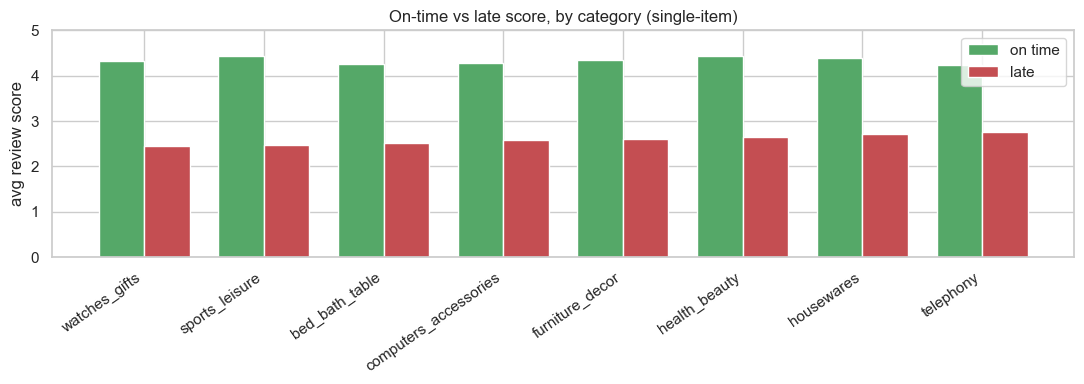

on_time,category_name,late_score,ontime_score,lateness_penalty
7,watches_gifts,2.45,4.33,1.88
5,sports_leisure,2.46,4.44,1.98
0,bed_bath_table,2.52,4.25,1.73
1,computers_accessories,2.58,4.29,1.71
2,furniture_decor,2.60,4.35,1.75
3,health_beauty,2.65,4.43,1.78
4,housewares,2.71,4.40,1.69
6,telephony,2.75,4.24,1.48


In [10]:
# Same on-time/late gap within the 8 most common categories — is the penalty uniform there too?
top_cats = si["category_name"].value_counts().head(8).index
cat_gap = gap_table(si[si["category_name"].isin(top_cats)], "category_name").sort_values("late_score")

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(cat_gap)); w = 0.38
ax.bar(x - w/2, cat_gap["ontime_score"], w, label="on time", color="#55A868")
ax.bar(x + w/2, cat_gap["late_score"], w, label="late", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(cat_gap["category_name"], rotation=35, ha="right")
ax.set_ylim(0, 5); ax.set_ylabel("avg review score"); ax.set_title("On-time vs late score, by category (single-item)")
ax.legend()
plt.tight_layout(); plt.show()
cat_gap.round(2)

**Interpretation.** Same story by category: **on-time ≈ 4.3★, late ≈ 2.5★** in every one. The
lateness→dissatisfaction effect is **robust** — not a proxy for distance, weight, or category.

## 6. How accurate are the estimates — and what are they based on? (question B)

Orders arrive ~12 days early on average, but that padding isn't even. Two questions: which states get
tight (risky) estimates, and **is the estimate model driven by distance or by actual delivery
performance?**

In [11]:
# Is the promised window (est_window = days from purchase to the estimate) driven by distance or by
# how long delivery actually takes? Compare the two correlations.
print("corr(distance, promised window):", round(d["dist_km"].corr(d["est_window"]), 3),
      "| corr(actual delivery days, promised window):", round(d["delivery_time_days"].corr(d["est_window"]), 3))

corr(distance, promised window): 0.516 | corr(actual delivery days, promised window): 0.385


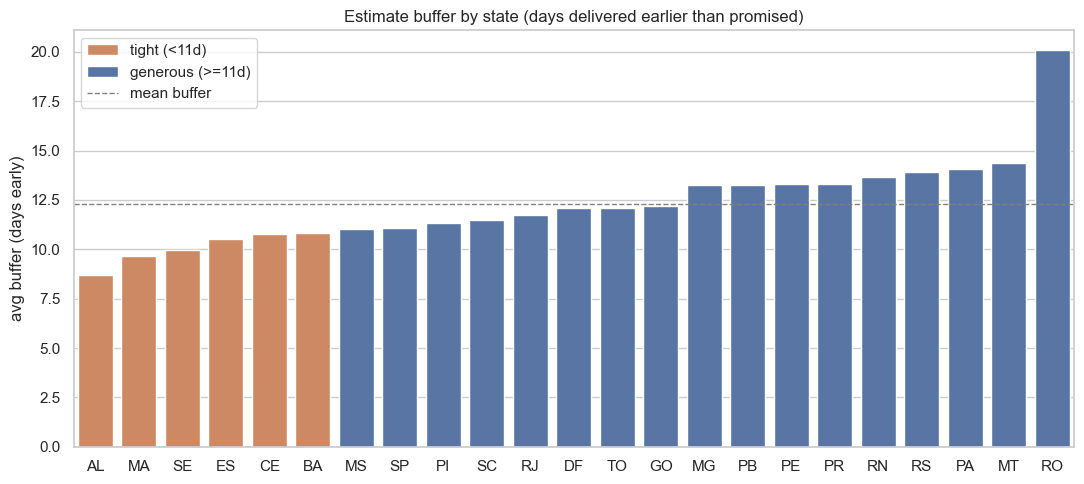

,state,orders,avg_buffer_days,on_time_pct,avg_delivery_days,buffer_tier
19,AL,396,8.70,76.00,24.50,tight (<11d)
2,MA,714,9.60,80.50,21.40,tight (<11d)
9,SE,334,10.00,84.70,21.50,tight (<11d)
4,ES,1989,10.50,87.90,15.70,tight (<11d)
7,CE,1275,10.80,84.60,21.20,tight (<11d)
11,BA,3248,10.80,86.10,19.30,tight (<11d)


In [12]:
# Buffer per state (>=200 delivered orders): average cushion, on-time rate, delivery time.
est = q('''
    select delivery_state as state, count(*) as orders,
           avg(datediff('day', delivered_to_customer_at, estimated_delivery_date)) as avg_buffer_days,
           avg(iff(is_delivered_on_time, 1, 0)) * 100 as on_time_pct,
           avg(delivery_time_days) as avg_delivery_days
    from dev_marts.fct_orders
    where status = 'delivered' and delivered_to_customer_at is not null and delivery_state is not null
    group by 1 having count(*) >= 200
''')
est_sorted = est.sort_values("avg_buffer_days")
# Semantic hue: tight (<11d) vs generous cushion — gives the colours meaning + a legend, seaborn-safe.
est_sorted["buffer_tier"] = np.where(est_sorted["avg_buffer_days"] < 11, "tight (<11d)", "generous (>=11d)")

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=est_sorted, x="state", y="avg_buffer_days", ax=ax, order=est_sorted["state"],
            hue="buffer_tier", palette={"tight (<11d)": "#DD8452", "generous (>=11d)": "#4C72B0"}, dodge=False)
ax.axhline(est_sorted["avg_buffer_days"].mean(), color="grey", ls="--", lw=1, label="mean buffer")
ax.set_title("Estimate buffer by state (days delivered earlier than promised)")
ax.set_xlabel(""); ax.set_ylabel("avg buffer (days early)"); ax.legend()
plt.tight_layout(); plt.show()
est_sorted.head(6).round(1)

**Interpretation — the estimate is padded by *distance*, not by *performance*.** The promised
window correlates **~0.52 with distance** but only **~0.39 with actual delivery time**. So the model
stretches the promise for far customers, but it doesn't account for routes that are *slow for their
distance*. The tightest-buffer states (AL, MA, SE) are exactly the **slowest** (21–24 days) and least
reliable (76–85% on-time) — the periphery is systematically under-padded. That sets up the fix in §7.

## 7. Is it distance, or logistics? — geographic equity (question D)

If delivery time were purely about distance, every state would sit on one line. States **above** that
line are *slower than their distance predicts* — a **logistics** problem, not a geography one.

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_18587/578783577.py:22: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/Users/divija/Claude Projects/data-portfolio-projects/retail-platform-analytics/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


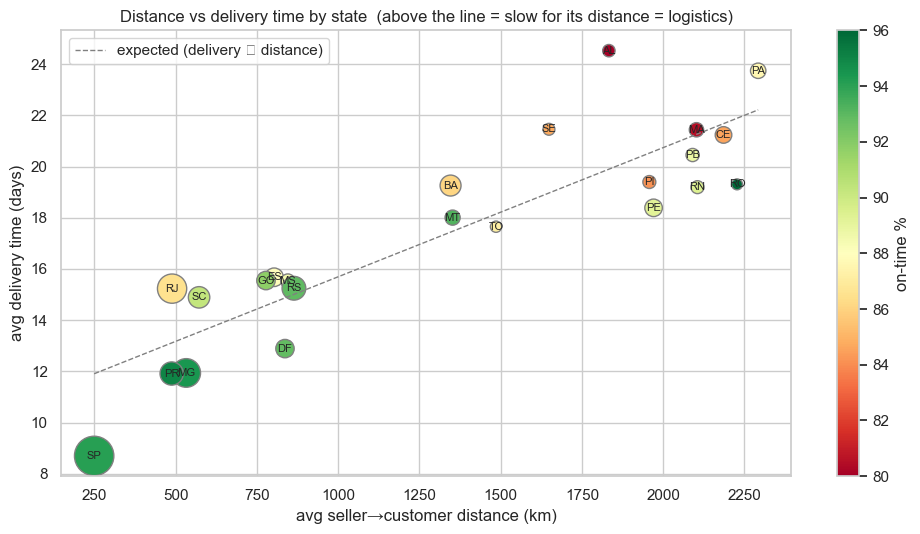

,delivery_state,orders,dist_km,avg_days,on_time_pct,buffer,avg_score,slower_than_dist_predicts
1,AL,396,"1,833.00",24.50,76.00,8.70,3.90,4.60
24,SE,334,"1,648.70",21.50,84.70,10.00,3.90,2.50
18,RJ,12300,489.30,15.20,86.50,11.80,4.00,2.10
4,BA,3238,"1,346.00",19.30,86.10,10.80,3.90,1.80
13,PA,944,"2,292.40",23.70,87.60,14.00,3.90,1.50
23,SC,3537,572.30,14.90,90.30,11.50,4.10,1.40
7,ES,1984,803.20,15.70,87.90,10.50,4.10,1.00
8,GO,1944,778.10,15.50,91.80,12.20,4.10,1.00


In [13]:
# One row per state (>=500 delivered orders): volume, distance, speed, reliability, satisfaction, buffer.
state = d.groupby("delivery_state").agg(
    orders=("order_id", "size"), dist_km=("dist_km", "mean"),
    avg_days=("delivery_time_days", "mean"), on_time_pct=("on_time", "mean"),
    avg_score=("review_score", "mean"), buffer=("est_buffer_days", "mean")).reset_index()
state = state[state["orders"] >= 200].copy()    # same threshold as §6 so AL/SE/MA appear here too
state["on_time_pct"] *= 100
# Fit delivery-days ~ distance across states; the residual = days SLOWER than distance predicts (>0 = logistics drag).
b1, b0 = np.polyfit(state["dist_km"], state["avg_days"], 1)
state["slower_than_dist_predicts"] = state["avg_days"] - (b0 + b1 * state["dist_km"])

fig, ax = plt.subplots(figsize=(10, 5.5))
xs = np.linspace(state["dist_km"].min(), state["dist_km"].max(), 50)
ax.plot(xs, b0 + b1 * xs, color="grey", ls="--", lw=1, label="expected (delivery ∝ distance)")
sc = ax.scatter(state["dist_km"], state["avg_days"], s=np.sqrt(state["orders"]) * 4,
                c=state["on_time_pct"], cmap="RdYlGn", vmin=80, vmax=96, edgecolor="grey")
for _, r in state.iterrows():
    ax.annotate(r["delivery_state"], (r["dist_km"], r["avg_days"]), fontsize=8, ha="center", va="center")
plt.colorbar(sc, label="on-time %"); ax.legend()
ax.set_xlabel("avg seller→customer distance (km)"); ax.set_ylabel("avg delivery time (days)")
ax.set_title("Distance vs delivery time by state  (above the line = slow for its distance = logistics)")
plt.tight_layout(); plt.show()
# States most slow-for-their-distance (logistics-bottlenecked), worst first:
state.sort_values("slower_than_dist_predicts", ascending=False)[
    ["delivery_state", "orders", "dist_km", "avg_days", "on_time_pct", "buffer",
     "avg_score", "slower_than_dist_predicts"]].round(1).head(8)

**Interpretation — RJ is a logistics problem, not a distance one.** Most states line up: delivery
time rises with distance. The ones **above** the line are slow for how close they are — **AL (+4.6d),
SE (+2.5d), RJ (+2.1d), BA (+1.8d)**. **RJ vs RS is the clearest case:** both deliver in ~15 days, but RS
is *farther* (864 vs 489 km) — so RS is efficient for its distance while RJ is slow. Because the estimate
is distance-based, close-in RJ gets a *shorter* promised window (~27d) than far RS (~29d), so despite the
same actual speed RJ's cushion is thinner (11.8 vs 13.9d) and its variance higher (σ 11.5 vs 9.1) →
**86.5% on-time / 3.97★ vs RS's 93% / 4.19★**. Same speed, different *reliability* — and satisfaction
tracks reliability.

## 8. The correlation picture (and its limits)

One place to see how the numeric factors relate. **These are correlations, not isolated causes** — the
controlled cuts in §4–§5 are what actually pin lateness/speed as the drivers; distance and weight look
impactful here only *through* delivery time.

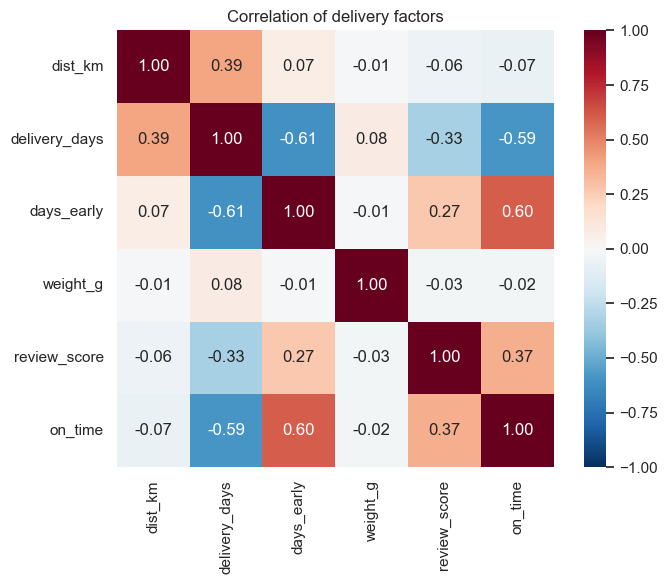

In [14]:
# Pairwise correlations across the order-level factors (on_time cast to 1/0).
corr_df = d[["dist_km", "delivery_time_days", "est_buffer_days", "weight_g", "review_score"]].copy()
corr_df["on_time"] = d["on_time"].map({True: 1.0, False: 0.0})
corr_df = corr_df.rename(columns={"est_buffer_days": "days_early", "delivery_time_days": "delivery_days"})
cmat = corr_df.corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cmat, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0, ax=ax, square=True)
ax.set_title("Correlation of delivery factors")
plt.tight_layout(); plt.show()

**Interpretation.** The satisfaction column tells the whole story: **on-time (0.37)** and
**days-early (0.27)** are the strongest links to `review_score`, and **delivery days (−0.34)** the
strongest negative — i.e. *reliability and speed*. **Distance (−0.06) and weight (−0.03) barely move the
score directly**; they act only via delivery time (distance↔delivery-days 0.40). This is the numeric
echo of §4–§5: fix delivery, and satisfaction follows.

## 9. Findings & recommendations

### What we established
1. **Lateness is the causal driver of dissatisfaction** — controlling for distance, weight and category,
   on-time ≈ 4.3★ vs late ≈ 2.5★ everywhere. And it's a **gradient with a cliff**: a small miss already
   hurts, 7+ days late craters to ~1.7★.
2. **Speed matters even when on-time** (4.43 → 3.94 from <7 to 21+ days); the *size* of the early cushion
   barely does. Reliability + speed, not distance or weight, drive the score.
3. **The estimate model is distance-based, not performance-based** (corr 0.52 vs 0.39), so routes that are
   *slow for their distance* get under-padded and miss the promise most.
4. **Delivery is inequitable, and it's partly logistics, not just geography** — RJ/AL/SE/BA are slower
   than their distance predicts; RJ (close to the hub yet ~+2 days slow) is the clearest bottleneck.

### Recommendations (hypotheses to validate on live data)
**Lever A — fix the estimates (cheap, fast).**
- Base the promised date on **actual route performance**, not just distance; **pad the window for
  slow-for-distance states** (RJ, AL, SE, BA) and the slow periphery (MA, CE). This recovers on-time rate
  — the real satisfaction driver — with no operational change.

**Lever B — fix the logistics (root cause).**
- **Audit RJ** first: near the São Paulo hub yet ~2 days slower than distance predicts and high-variance —
  a fixable carrier/hand-off bottleneck, *not* solved by a new hub.
- For genuinely **far, high-volume** states (BA ~3.2k orders at 19 days, plus PE, CE), evaluate a
  **Northeast fulfilment hub or regional stocking** to cut delivery time at the source.
- **Protect on-time on long routes above all** — a fast, reliable far delivery scores like a local one.

### Related notebooks
- `03_customer_value_and_behavior.ipynb` — what makes a customer valuable, and why repeat is low.
- `04_category_and_freight_economics.ipynb` — freight-as-margin-proxy by category and weight.